# 00 — From invoices to a heterogeneous graph

This notebook builds the first real graph used by the project. It is written as a studybook: no prior graph-machine-learning knowledge is assumed.

By the end, you should be able to explain:

1. what nodes, edges, node features, and labels mean;
2. why this is a **heterogeneous**, **bipartite-style** graph;
3. why buyer/seller roles belong on edges rather than in separate company identities;
4. how PyTorch Geometric (PyG) stores typed graph relations;
5. how the cutoff prevents future data from influencing feature fitting and company history;
6. what graph construction does—and deliberately does not—solve.

The reusable implementation lives in `src/graph_ml/data/graph.py`; the notebook explains and exercises it rather than hiding production logic in cells.

## 1. The business table and the graph view

The input table has one row per financed invoice, called an **instrument**. Each instrument connects two companies:

- the **seller/customer**, which sold goods or services and financed the receivable;
- the **buyer/debtor**, which owes the invoice payment.

In a normal table those company identities are just two columns. In a graph they become shared nodes, so two invoices involving the same company become structurally connected.

A graph can be written as $G=(V,E)$:

- $V$ is the set of **vertices**, or nodes;
- $E$ is the set of **edges**, or relationships between nodes.

Here, $V = V_{instrument} \cup V_{company}$. Because there are multiple node and relation types, this is a **heterogeneous graph**. It is bipartite-style because every edge crosses between an instrument and a company; there are no direct instrument→instrument or company→company edges in v1.

```mermaid
graph LR
    I1[Instrument 1] -->|sold_by| C1[Company A]
    I1 -->|owed_by| C2[Company B]
    I2[Instrument 2] -->|sold_by| C3[Company C]
    I2 -->|owed_by| C1
```

Company A is a **hybrid**: it is a seller on Instrument 1 and a buyer on Instrument 2. This is why the implementation creates one company node per normalized company name and puts the business role on the edge. Splitting companies into disjoint buyer and seller node types would cut this bridge in two.

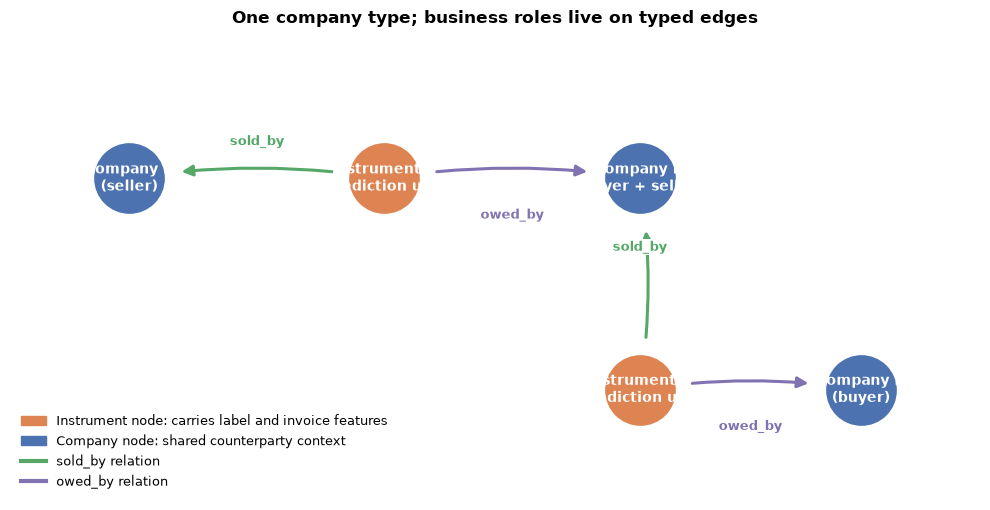

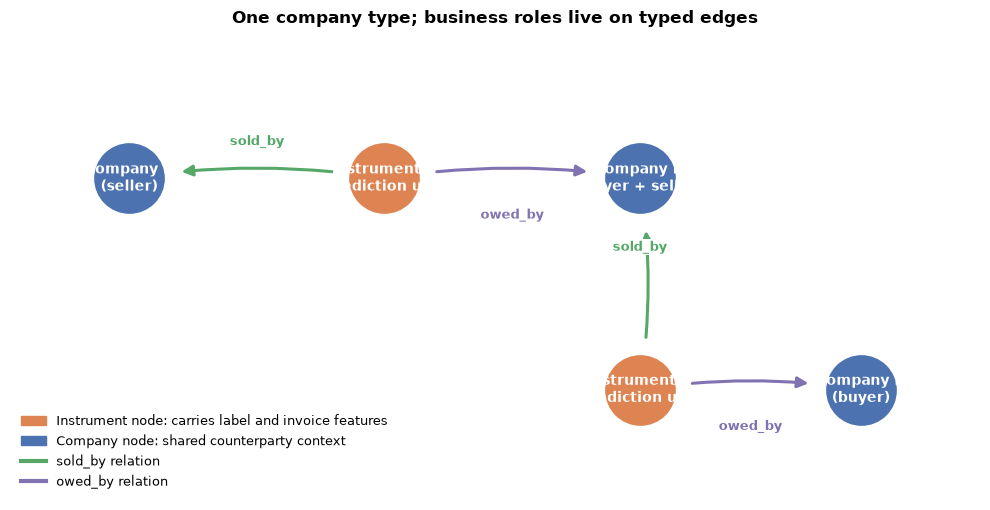

In [1]:
from graph_ml.viz import plot_graph_schema

plot_graph_schema()

Read the orange circles as the things we score and the blue circles as shared context. The arrow color carries the economic role. Company H remains one node even though it appears on opposite sides of two transactions; this preserved bridge is precisely what lets information travel farther than a single invoice row.

## 2. What information lives where?

| Graph object | Meaning here | Tensor form |
|---|---|---|
| Instrument node | One invoice; the prediction unit | one row in `instrument.x` |
| Company node | One canonical company identity | one row in `company.x` |
| Role-typed edge | Seller or buyer relationship | one column in an `edge_index` |
| Instrument label | Whether the invoice was impaired | one value in `instrument.y` |
| Node feature | Numeric description available to the model | one column in an `x` matrix |

A node's integer tensor row is an internal index, not its business identifier. The builder therefore returns metadata mappings alongside the graph. This avoids trying to place strings such as invoice UIDs inside model tensors.

## 3. Identity resolution: conservative normalization

Buyer IDs and seller IDs come from separate namespaces, so the same company has different IDs in the two roles. The thesis data can identify hybrids only by company name.

The normalizer applies Unicode compatibility normalization, case-folding, trimming, and whitespace collapsing. It intentionally keeps punctuation: aggressive fuzzy matching could silently merge two distinct legal entities.

In [2]:
from pathlib import Path

import torch

from graph_ml.data import (
    GraphBuildConfig,
    build_trade_finance_graph_from_parquet,
    canonicalize_company_name,
)

examples = ["  ACME   GmbH ", "acme gmbh", "ACME\u00a0GmbH"]
[canonicalize_company_name(name) for name in examples]

['acme gmbh', 'acme gmbh', 'acme gmbh']

All three display variants map to the same key. The original spelling is still retained as display metadata, but the canonical key determines graph identity.

## 4. Leakage starts during graph construction

Suppose the prediction cutoff is $T$. A model simulates what could have been known then:

- feature statistics are fitted only on instruments with `invoice_date < T`;
- company histories aggregate only those pre-$T$ instruments;
- categories first observed after $T$ go to an explicit `__unknown__` feature;
- companies first observed after $T$ receive an all-zero history vector.

For a numeric feature $x$, the training-history transformation is

$$z = \frac{x - \mu_{pre-T}}{\sigma_{pre-T}}.$$

Using a mean or vocabulary fitted on the entire table would let the future influence the representation, even without using the target label directly.

### Feature policy

Instrument features are restricted to attributes plausibly known around origination:

- log invoice amount;
- purchase amount divided by invoice amount;
- payment term (`due_date - invoice_date`);
- system input lag (`input_date - invoice_date`);
- one-hot currency and factoring type.

Columns such as `last_payment_date`, `total_impairment`, `purchase_amount_open`, and final document status describe later lifecycle events. Feeding them into an origination-time model would reveal part of the answer.

Company features contain role-specific pre-cutoff counts and means of the four numeric origination features. They deliberately exclude historical outcome rates for now: the non-snapshot table records eventual outcomes, not a fully proven as-of-cutoff state. This conservative version can be expanded once temporal snapshot semantics establish exactly which outcomes were known by $T$.

For company $c$ and role $r$, a history mean is

$$h_{c,r,j} = \frac{1}{|I_{c,r}^{<T}|}\sum_{i \in I_{c,r}^{<T}} z_{i,j},$$

where $I_{c,r}^{<T}$ is the set of pre-cutoff instruments involving company $c$ in role $r$. If that set is empty, the feature is zero. Seller and buyer aggregates remain separate so a hybrid's two business roles are not blended.

## 5. Build the real graph

The real anonymized dataset is local and gitignored. This notebook's committed outputs contain only aggregate graph information—no invoice rows or company names.

In [3]:
repo_root = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "pyproject.toml").exists()
)
data_path = repo_root / "data/02_instrumentsdf_2.parquet"
if not data_path.exists():
    raise FileNotFoundError(
        "The real local Parquet data is required; see wiki/this-project/data-availability.md"
    )

config = GraphBuildConfig(cutoff="2018-04-30", label_column="has_impairment1")
result = build_trade_finance_graph_from_parquet(data_path, config)
graph = result.graph
metadata = result.metadata
graph

HeteroData(
  instrument={
    x=[59820, 12],
    y=[59820],
    node_id=[59820],
    invoice_date=[59820],
    pre_cutoff_mask=[59820],
  },
  company={
    x=[3349, 10],
    node_id=[3349],
  },
  (instrument, sold_by, company)={ edge_index=[2, 59820] },
  (company, sells, instrument)={ edge_index=[2, 59820] },
  (instrument, owed_by, company)={ edge_index=[2, 59820] },
  (company, owes, instrument)={ edge_index=[2, 59820] }
)

`HeteroData` acts like a dictionary keyed first by node type and then by an edge-type triple `(source_type, relation, destination_type)`. The `x=[59820, 12]` notation means 59,820 instrument nodes with 12 features each.

In [4]:
seller_company_indices = set(
    graph["instrument", "sold_by", "company"].edge_index[1].tolist()
)
buyer_company_indices = set(
    graph["instrument", "owed_by", "company"].edge_index[1].tolist()
)

summary = {
    "instrument_nodes": graph["instrument"].num_nodes,
    "company_nodes": graph["company"].num_nodes,
    "business_role_edges": (
        graph["instrument", "sold_by", "company"].num_edges
        + graph["instrument", "owed_by", "company"].num_edges
    ),
    "stored_directed_edges_including_reverses": sum(
        graph[edge_type].num_edges for edge_type in graph.edge_types
    ),
    "pre_cutoff_instruments": int(graph["instrument"].pre_cutoff_mask.sum()),
    "post_cutoff_instruments": int((~graph["instrument"].pre_cutoff_mask).sum()),
    "zero_history_companies": int(
        (graph["company"].x.abs().sum(dim=1) == 0).sum()
    ),
    "hybrid_companies": len(seller_company_indices & buyer_company_indices),
}
summary

{'instrument_nodes': 59820,
 'company_nodes': 3349,
 'business_role_edges': 119640,
 'stored_directed_edges_including_reverses': 239280,
 'pre_cutoff_instruments': 46102,
 'post_cutoff_instruments': 13718,
 'zero_history_companies': 849,
 'hybrid_companies': 15}

Every instrument has exactly two business-role edges: one seller and one buyer. PyG also needs reverse relations if information should flow company→instrument as well as instrument→company, so four directed edge stores represent two underlying business links per instrument.

### A small piece of the real graph

A 63,169-node graph cannot be understood as one hairball. Instead, we inspect a bounded **ego graph**: one focal hybrid company, a sample of its connected instruments in each role, and the companies on the other ends. Labels are deliberately generic (`C0`, `I0`, …); colors retain the semantics without exposing business identities.

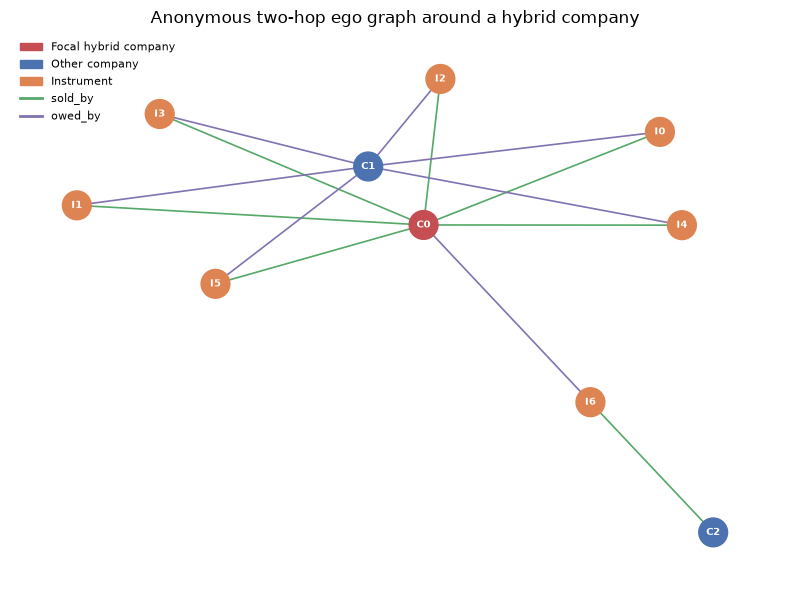

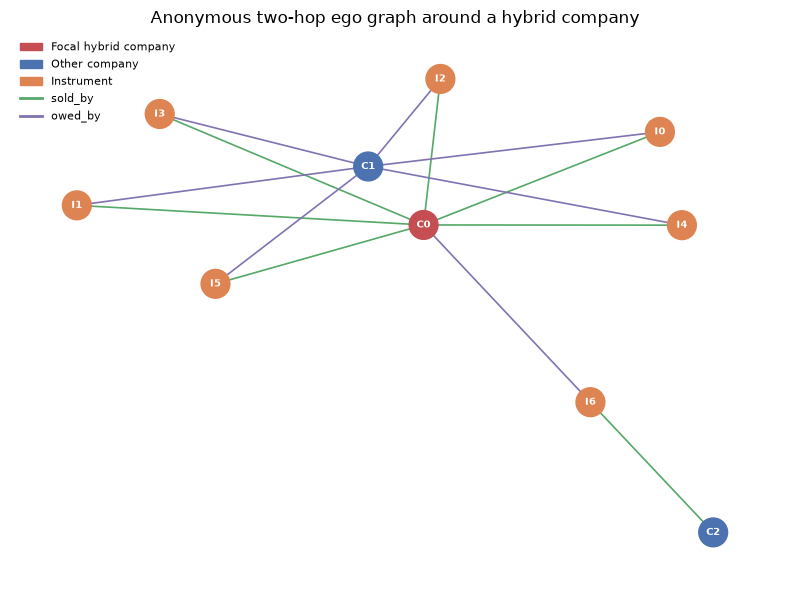

In [5]:
from graph_ml.viz import (
    anonymous_company_ego_graph,
    company_degree_frame,
    plot_anonymous_ego_graph,
)

degrees = company_degree_frame(graph)
focal_hybrid = int(
    degrees.loc[degrees["is_hybrid"]]
    .sort_values("total_degree", ascending=False)
    .iloc[0]["company_index"]
)
ego = anonymous_company_ego_graph(
    graph, focal_hybrid, max_instruments_per_role=6
)
plot_anonymous_ego_graph(ego)

The red focal company participates in both green seller edges and purple buyer edges. Each orange instrument connects exactly two companies. A path such as `I0 → C0 → I4` means that two instruments share a counterparty; it does **not** mean one invoice directly caused the other. The graph encodes relational opportunity for learning, not causality.

## 6. How `edge_index` represents edges

PyG uses a coordinate list rather than a dense adjacency matrix. An edge tensor has shape `[2, number_of_edges]`:

$$\text{edge\_index} = \begin{bmatrix} source_0 & source_1 & \cdots \\ destination_0 & destination_1 & \cdots \end{bmatrix}.$$

For `instrument --sold_by--> company`, the first row indexes instrument nodes and the second indexes company nodes. This costs $O(E)$ storage. A dense instrument-by-company adjacency matrix would reserve space for almost every possible pair even though nearly all pairs are absent.

In [6]:
sold_by = graph["instrument", "sold_by", "company"].edge_index
sells = graph["company", "sells", "instrument"].edge_index

edge_checks = {
    "sold_by_shape": tuple(sold_by.shape),
    "reverse_is_exact_flip": bool(torch.equal(sells, sold_by.flip(0))),
    "one_seller_edge_per_instrument": sold_by.shape[1]
    == graph["instrument"].num_nodes,
}
edge_checks

{'sold_by_shape': (2, 59820),
 'reverse_is_exact_flip': True,
 'one_seller_edge_per_instrument': True}

## 7. What a GNN will do with this later

A message-passing layer repeatedly performs two conceptual operations:

1. **aggregate** information arriving from neighboring nodes;
2. **update** each node representation using its old state and the aggregate.

On this graph, the first hop can move instrument information into company nodes. A second hop can move an aggregated company representation back into related instruments. Relation-aware layers can learn different transformations for `sold_by` and `owed_by`, preserving the economic asymmetry.

Graph construction itself does not train a GNN. It defines the objects and tensors on which later message passing operates.

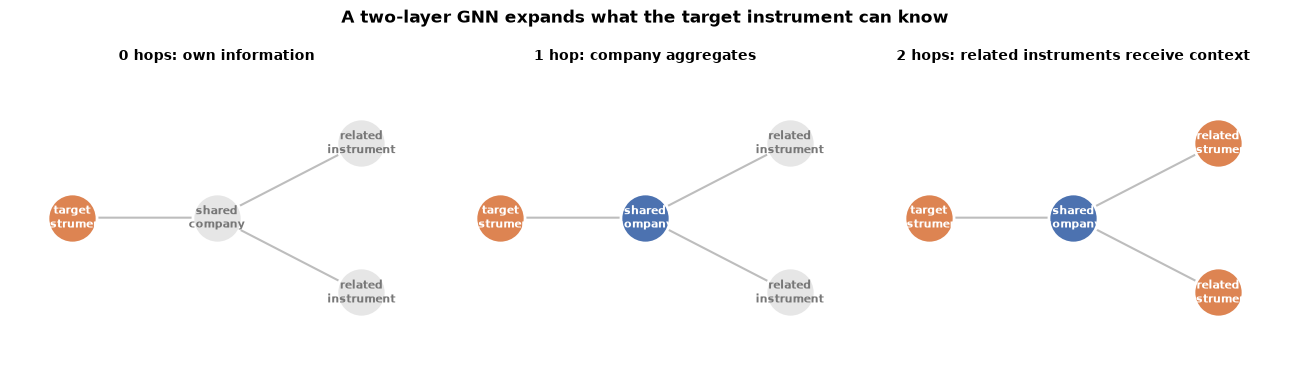

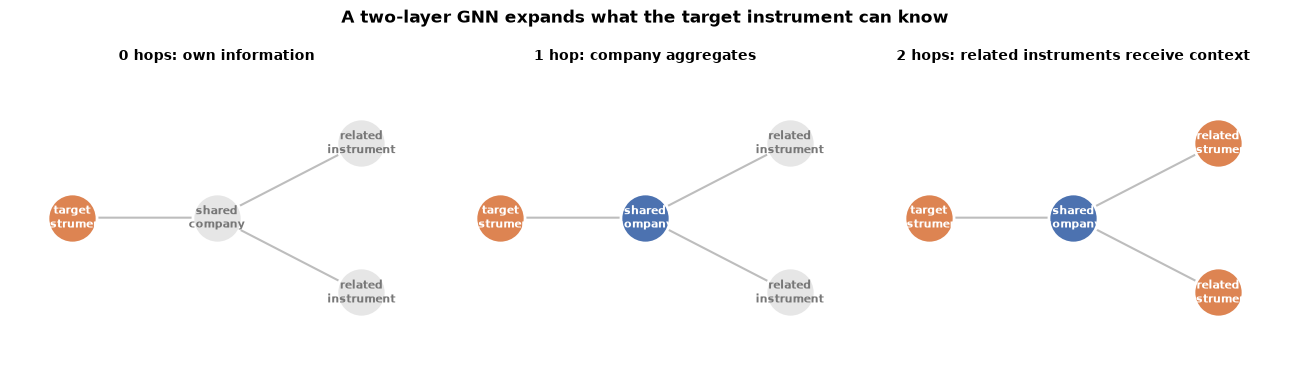

In [7]:
from graph_ml.viz import plot_message_passing_steps

plot_message_passing_steps()

The panels show a node's **receptive field**: the set of nodes that can affect its representation. Before message passing, the target knows only its own feature row. After one layer, information can cross one edge. After two layers, the target can receive a summary of other instruments linked through a shared company. More layers reach farther, but can also blur useful differences and increase leakage risk if temporal edges are not controlled.

In [8]:
feature_shapes = {
    "instrument_x": tuple(graph["instrument"].x.shape),
    "company_x": tuple(graph["company"].x.shape),
    "instrument_labels": tuple(graph["instrument"].y.shape),
    "all_instrument_features_finite": bool(graph["instrument"].x.isfinite().all()),
    "all_company_features_finite": bool(graph["company"].x.isfinite().all()),
}
feature_shapes

{'instrument_x': (59820, 12),
 'company_x': (3349, 10),
 'instrument_labels': (59820,),
 'all_instrument_features_finite': True,
 'all_company_features_finite': True}

### Feature names are part of the contract

Tensor columns are otherwise anonymous numbers. Returning ordered names makes model inputs inspectable and prevents a silent mismatch between preprocessing and modelling.

In [9]:
print("Instrument features:")
for index, name in enumerate(metadata.instrument_feature_names):
    print(f"  {index:2d}: {name}")

print("\nCompany features:")
for index, name in enumerate(metadata.company_feature_names):
    print(f"  {index:2d}: {name}")

Instrument features:
   0: log_invoice_amount
   1: purchase_to_invoice_ratio
   2: payment_term_days
   3: input_lag_days
   4: currency=Britisches Pfund
   5: currency=Euro
   6: currency=Schweizer Franken
   7: currency=US-Dollar
   8: currency=__unknown__
   9: factoring_type=Full Service
  10: factoring_type=Reverse Factoring
  11: factoring_type=__unknown__

Company features:
   0: seller_history_log_count
   1: seller_history_mean_log_invoice_amount
   2: seller_history_mean_purchase_to_invoice_ratio
   3: seller_history_mean_payment_term_days
   4: seller_history_mean_input_lag_days
   5: buyer_history_log_count
   6: buyer_history_mean_log_invoice_amount
   7: buyer_history_mean_purchase_to_invoice_ratio
   8: buyer_history_mean_payment_term_days
   9: buyer_history_mean_input_lag_days


## 8. Boundaries and next step

This build establishes topology, cutoff-safe feature fitting, and metadata. It does **not** yet define the final training/evaluation population:

- `pre_cutoff_mask` records temporal position, but is not automatically a training mask;
- label maturity still needs to exclude unresolved outcomes;
- the next pipeline component must construct the inductive train/test views and seen/cold-start breakdown;
- the static v1 still accepts some within-training temporal mixing once message passing begins; strictly causal temporal message passing is deferred and must remain an explicit limitation.

Keeping graph construction separate from evaluation makes each assumption visible and independently testable.

## Takeaways

- The graph preserves invoices as label-bearing nodes and companies as shared structural context.
- One canonical company type plus role-typed edges correctly represents buyer/seller hybrids.
- Reverse relations are required for bidirectional message flow; they do not represent additional business transactions.
- Preprocessing is part of leakage control: fit statistics, vocabularies, and company histories only before the cutoff.
- Cold-start companies receive a meaningful zero-history representation rather than an untrained ID embedding.
- The code intentionally excludes lifecycle and eventual-outcome features whose availability at prediction time is not defensible.
- Graph construction creates a trustworthy representation; temporal splitting and label maturity are the next step.